# Odisha Rice Yield — Integrated Dataset & Complete EDA

### Project objective
Build a clean, integrated dataset for **Rice yield analysis in Odisha** by combining:

1. District/season/crop-wise agricultural statistics for Odisha.
2. An integrated Odisha Rice dataset containing climate, soil, nutrient and irrigation variables.

The notebook then performs a complete **data validation, cleaning and exploratory data analysis (EDA)** on the final district-level Rice dataset.

> **Important:** This notebook stops before model training. The final cleaned dataset is prepared for the ML stage at the end.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

## 2. Load the two datasets


In [2]:
DATASET1_PATH = "district-season-and-crop-wise-area-production-and-yield-statistics-for-odisha.csv"
DATASET2_PATH = "Integrated_Odisha_Rice_Yield_Dataset_2014_2024.csv"

df1 = pd.read_csv(DATASET1_PATH)
df2 = pd.read_csv(DATASET2_PATH)

print("Dataset 1 shape:", df1.shape)
print("Dataset 2 shape:", df2.shape)

Dataset 1 shape: (19383, 12)
Dataset 2 shape: (900, 19)


In [3]:
display(df1.head())
display(df2.head())

,fiscal_year,state,district_as_per_source,district_as_per_lgd,district_lgd_code,crop,season,area,production,crop_yield,unit,note
0,2024-25,Odisha,Sundargarh,Sundargarh,373.0,Sugarcane,Kharif,29.01,3384.35,116666.0,"area in Hectares, production in Tonnes, crop_y...",NaN
1,2024-25,Odisha,Jharsuguda,Jharsuguda,357.0,Sugarcane,Kharif,70.02,6287.87,89800.0,"area in Hectares, production in Tonnes, crop_y...",NaN
2,2024-25,Odisha,Balangir,Balangir,345.0,Sugarcane,Kharif,25.01,1862.23,74467.0,"area in Hectares, production in Tonnes, crop_y...",NaN
3,2024-25,Odisha,Cuttack,Cuttack,350.0,Sugarcane,Kharif,225.07,16348.85,72640.0,"area in Hectares, production in Tonnes, crop_y...",NaN
4,2024-25,Odisha,Dhenkanal,Dhenkanal,352.0,Sugarcane,Kharif,574.17,41540.09,72348.0,"area in Hectares, production in Tonnes, crop_y...",NaN


,fiscal_year,state,district_as_per_source,district_as_per_lgd,district_lgd_code,crop,season,area,production,crop_yield,year,avg_temperature_c,rainfall_mm,humidity_pct,soil_ph,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,irrigation_pct
0,2024-25,Odisha,Sambalpur,Sambalpur,371.0,Rice,Summer,16603.88,69639.30,4194.0,2024,29.6,1187.0,85.3,5.43,303.0,29.0,177.0,62.0
1,2024-25,Odisha,Sonepur,Sonepur,372.0,Rice,Summer,40999.70,156856.79,3826.0,2024,27.6,1327.0,80.9,5.29,289.0,23.0,176.0,32.0
2,2024-25,Odisha,Jharsuguda,Jharsuguda,357.0,Rice,Summer,1951.99,7162.65,3669.0,2024,28.5,1516.0,87.7,5.56,271.0,23.0,177.0,45.0
3,2024-25,Odisha,Bargarh,Bargarh,347.0,Rice,Summer,100936.27,367524.57,3641.0,2024,30.4,1484.0,87.8,6.18,262.0,23.0,187.0,69.0
4,2024-25,Odisha,Khordha,Khordha,362.0,Rice,Summer,1752.99,6083.98,3471.0,2024,29.8,1297.0,80.3,6.14,279.0,27.0,158.0,44.0


## 3. Initial inspection of both datasets

In [4]:
print("Dataset 1 information")
df1.info()

print("\nDataset 2 information")
df2.info()

Dataset 1 information
<class 'pandas.DataFrame'>
RangeIndex: 19383 entries, 0 to 19382
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fiscal_year             19383 non-null  str    
 1   state                   19383 non-null  str    
 2   district_as_per_source  19383 non-null  str    
 3   district_as_per_lgd     18507 non-null  str    
 4   district_lgd_code       18507 non-null  float64
 5   crop                    19383 non-null  str    
 6   season                  19383 non-null  str    
 7   area                    19383 non-null  float64
 8   production              19352 non-null  float64
 9   crop_yield              19352 non-null  float64
 10  unit                    19383 non-null  str    
 11  note                    0 non-null      float64
dtypes: float64(5), str(7)
memory usage: 1.8 MB

Dataset 2 information
<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data c

In [5]:
print("Dataset 1 descriptive statistics")
display(df1.describe(include="all").T)

print("Dataset 2 descriptive statistics")
display(df2.describe(include="all").T)

Dataset 1 descriptive statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fiscal_year,19383,28,1999-00,1168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,19383,1,Odisha,19383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_as_per_source,19383,35,State Total,876,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_as_per_lgd,18507,30,Sundargarh,734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_lgd_code,18507.0,NaN,NaN,NaN,358.565516,8.746299,344.0,351.0,359.0,366.0,373.0
crop,19383,40,Rice,2133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,19383,6,Winter,5716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,19383.0,NaN,NaN,NaN,15233.073214,147921.604926,0.33,67.0,421.0,2315.5,8629000.0
production,19352.0,NaN,NaN,NaN,25682.132068,250405.839623,0.0,41.915,360.0,2770.4,9978410.0
crop_yield,19352.0,NaN,NaN,NaN,211.157548,3239.75533,0.0,0.324963,0.720268,1.997752,147828.0


Dataset 2 descriptive statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fiscal_year,900,11,2016-17,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,900,1,Odisha,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_as_per_source,900,35,Sambalpur,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_as_per_lgd,869,30,Sambalpur,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_lgd_code,869.0,NaN,NaN,NaN,358.696203,8.665427,344.0,351.0,359.0,366.0,373.0
crop,900,1,Rice,900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,900,4,Summer,323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,900.0,NaN,NaN,NaN,96854.417822,362617.120493,2.0,1841.175,29000.0,88907.75,3700737.0
production,870.0,NaN,NaN,NaN,226615.853701,858492.080797,0.0,4753.3,58987.65,209160.2,9978410.0
crop_yield,870.0,NaN,NaN,NaN,249.211377,750.9638,0.0,1.6925,2.375045,3.088782,4194.0


In [6]:
print("Dataset 1 missing values")
display(df1.isnull().sum().sort_values(ascending=False))

print("Dataset 2 missing values")
display(df2.isnull().sum().sort_values(ascending=False))

Dataset 1 missing values


note                      19383
district_as_per_lgd         876
district_lgd_code           876
production                   31
crop_yield                   31
district_as_per_source        0
fiscal_year                   0
state                         0
area                          0
season                        0
crop                          0
unit                          0
dtype: int64

Dataset 2 missing values


district_as_per_lgd       31
district_lgd_code         31
crop_yield                30
production                30
district_as_per_source     0
fiscal_year                0
state                      0
season                     0
crop                       0
area                       0
year                       0
avg_temperature_c          0
rainfall_mm                0
humidity_pct               0
soil_ph                    0
nitrogen_kg_ha             0
phosphorus_kg_ha           0
potassium_kg_ha            0
irrigation_pct             0
dtype: int64

## 4. Identify the common structure

The two datasets share the key fields needed to connect a Rice observation to its environmental information.

In [7]:
common_columns = sorted(set(df1.columns).intersection(df2.columns))
print("Common columns:")
print(common_columns)

Common columns:
['area', 'crop', 'crop_yield', 'district_as_per_lgd', 'district_as_per_source', 'district_lgd_code', 'fiscal_year', 'production', 'season', 'state']


## 5. Filter Dataset 1 to Rice

Dataset 2 contains Rice observations only, so Dataset 1 is filtered to Rice before integration.

In [8]:
rice_df1 = df1[df1["crop"].str.strip().str.lower() == "rice"].copy()

print("Rice rows in Dataset 1:", rice_df1.shape[0])
print("Rows in Dataset 2:", df2.shape[0])

Rice rows in Dataset 1: 2133
Rows in Dataset 2: 900


## 6. Check state-total records before merging

The source data contains aggregate `State Total` rows. These are not district-level observations and should not be included in the district-level ML dataset.

This filtering is done **before the merge**. This is important because both datasets contain missing district keys for State Total rows, and pandas can match missing merge keys.

In [9]:
print("State Total rows in Rice subset of Dataset 1:",
      (rice_df1["district_as_per_source"] == "State Total").sum())

print("State Total rows in Dataset 2:",
      (df2["district_as_per_source"] == "State Total").sum())

State Total rows in Rice subset of Dataset 1: 73
State Total rows in Dataset 2: 31


In [10]:
rice_df1 = rice_df1[rice_df1["district_as_per_source"] != "State Total"].copy()
df2_district = df2[df2["district_as_per_source"] != "State Total"].copy()

print("District-level Rice rows in Dataset 1:", rice_df1.shape[0])
print("District-level rows in Dataset 2:", df2_district.shape[0])

District-level Rice rows in Dataset 1: 2060
District-level rows in Dataset 2: 869


## 7. Validate district-name standardization

The source district names contain spelling/name variants. The LGD-standardized district field is retained for analysis.

In [11]:
print("Unique source district names:", rice_df1["district_as_per_source"].nunique())
print("Unique LGD district names:", rice_df1["district_as_per_lgd"].nunique())

mapping_check = (
    rice_df1[["district_as_per_source", "district_as_per_lgd"]]
    .drop_duplicates()
    .sort_values(["district_as_per_lgd", "district_as_per_source"])
)

display(mapping_check[mapping_check["district_as_per_source"] != mapping_check["district_as_per_lgd"]])

Unique source district names: 34
Unique LGD district names: 30


,district_as_per_source,district_as_per_lgd
49,Angul,Anugul
812,Baleshwar,Balasore
81,Jajpur,Jajapur
69,Keonjhar,Kendujhar


## 8. Define merge keys and check duplicates

A row is identified by:

- `fiscal_year`
- `district_lgd_code`
- `crop`
- `season`

In [12]:
merge_columns = [
    "fiscal_year",
    "district_lgd_code",
    "crop",
    "season"
]

print("Duplicate merge keys in Dataset 1:",
      rice_df1.duplicated(subset=merge_columns).sum())
print("Duplicate merge keys in Dataset 2:",
      df2_district.duplicated(subset=merge_columns).sum())

Duplicate merge keys in Dataset 1: 0
Duplicate merge keys in Dataset 2: 0


## 9. Validate the merge with an outer merge

The outer merge is used here only as a **diagnostic** to understand how many observations match.

In [13]:
merge_check = pd.merge(
    rice_df1,
    df2_district,
    on=merge_columns,
    how="outer",
    indicator=True,
    suffixes=("_dataset1", "_dataset2")
)

display(merge_check["_merge"].value_counts())

_merge
left_only     1191
both           869
right_only       0
Name: count, dtype: int64

In [14]:
print("Rows found in both datasets:", (merge_check["_merge"] == "both").sum())
print("Rows only in Dataset 1:", (merge_check["_merge"] == "left_only").sum())
print("Rows only in Dataset 2:", (merge_check["_merge"] == "right_only").sum())

Rows found in both datasets: 869
Rows only in Dataset 1: 1191
Rows only in Dataset 2: 0


### Interpretation

After removing State Total rows, the environmental dataset has **869 district-level observations**, and all 869 have corresponding Rice observations in Dataset 1. The remaining 1,191 Rice observations in Dataset 1 are outside the year/season coverage of the integrated environmental dataset.

## 10. Perform the final inner merge

For ML, we need observations where the agricultural and environmental records refer to the **same year, district, crop and season**.

In [15]:
merged_df = pd.merge(
    rice_df1,
    df2_district,
    on=merge_columns,
    how="inner",
    suffixes=("_crop", "_env")
)

print("Merged dataset shape:", merged_df.shape)
display(merged_df.head())

Merged dataset shape: (869, 27)


,fiscal_year,state_crop,district_as_per_source_crop,district_as_per_lgd_crop,district_lgd_code,crop,season,area_crop,production_crop,crop_yield_crop,unit,note,state_env,district_as_per_source_env,district_as_per_lgd_env,area_env,production_env,crop_yield_env,year,avg_temperature_c,rainfall_mm,humidity_pct,soil_ph,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,irrigation_pct
0,2024-25,Odisha,Sambalpur,Sambalpur,371.0,Rice,Summer,16603.88,69639.30,4194.0,"area in Hectares, production in Tonnes, crop_y...",NaN,Odisha,Sambalpur,Sambalpur,16603.88,69639.30,4194.0,2024,29.6,1187.0,85.3,5.43,303.0,29.0,177.0,62.0
1,2024-25,Odisha,Sonepur,Sonepur,372.0,Rice,Summer,40999.70,156856.79,3826.0,"area in Hectares, production in Tonnes, crop_y...",NaN,Odisha,Sonepur,Sonepur,40999.70,156856.79,3826.0,2024,27.6,1327.0,80.9,5.29,289.0,23.0,176.0,32.0
2,2024-25,Odisha,Jharsuguda,Jharsuguda,357.0,Rice,Summer,1951.99,7162.65,3669.0,"area in Hectares, production in Tonnes, crop_y...",NaN,Odisha,Jharsuguda,Jharsuguda,1951.99,7162.65,3669.0,2024,28.5,1516.0,87.7,5.56,271.0,23.0,177.0,45.0
3,2024-25,Odisha,Bargarh,Bargarh,347.0,Rice,Summer,100936.27,367524.57,3641.0,"area in Hectares, production in Tonnes, crop_y...",NaN,Odisha,Bargarh,Bargarh,100936.27,367524.57,3641.0,2024,30.4,1484.0,87.8,6.18,262.0,23.0,187.0,69.0
4,2024-25,Odisha,Khordha,Khordha,362.0,Rice,Summer,1752.99,6083.98,3471.0,"area in Hectares, production in Tonnes, crop_y...",NaN,Odisha,Khordha,Khordha,1752.99,6083.98,3471.0,2024,29.8,1297.0,80.3,6.14,279.0,27.0,158.0,44.0


## 11. Validate duplicated fields after merging

Both source files contain area, production and crop-yield fields. We compare them before selecting one version.

In [16]:
comparison_columns = [
    ("area_crop", "area_env"),
    ("production_crop", "production_env"),
    ("crop_yield_crop", "crop_yield_env")
]

for left_col, right_col in comparison_columns:
    diff = (merged_df[left_col] - merged_df[right_col]).abs()
    print(f"{left_col} vs {right_col}")
    print("  maximum absolute difference:", diff.max())
    print("  non-zero differences:", (diff > 1e-9).sum())

area_crop vs area_env
  maximum absolute difference: 0.0
  non-zero differences: 0
production_crop vs production_env
  maximum absolute difference: 0.0
  non-zero differences: 0
crop_yield_crop vs crop_yield_env
  maximum absolute difference: 0.0
  non-zero differences: 0


## 12. Build the final analysis dataset

The target must have a consistent unit. The original agricultural source uses tonnes/hectare for Rice, while the integrated dataset contains a unit break in the reported `crop_yield` values across years. Therefore, for analysis we recompute a consistent target:

**Yield (kg/ha) = Production (tonnes) × 1000 / Area (ha)**

`production` is retained for EDA/data validation, but it will **not** be used as an ML predictor because it is mathematically tied to yield.

In [17]:
final_df = merged_df[[
    "fiscal_year",
    "district_as_per_lgd_crop",
    "district_as_per_source_crop",
    "district_lgd_code",
    "season",
    "area_crop",
    "production_crop",
    "crop_yield_crop",
    "year",
    "avg_temperature_c",
    "rainfall_mm",
    "humidity_pct",
    "soil_ph",
    "nitrogen_kg_ha",
    "phosphorus_kg_ha",
    "potassium_kg_ha",
    "irrigation_pct"
]].copy()

final_df.rename(columns={
    "district_as_per_lgd_crop": "district",
    "district_as_per_source_crop": "district_source",
    "area_crop": "area",
    "production_crop": "production",
    "crop_yield_crop": "reported_crop_yield"
}, inplace=True)

final_df["yield_kg_ha"] = (
    final_df["production"] * 1000 / final_df["area"]
)

print("Integrated district-level shape:", final_df.shape)
display(final_df.head())

Integrated district-level shape: (869, 18)


,fiscal_year,district,district_source,district_lgd_code,season,area,production,reported_crop_yield,year,avg_temperature_c,rainfall_mm,humidity_pct,soil_ph,nitrogen_kg_ha,phosphorus_kg_ha,potassium_kg_ha,irrigation_pct,yield_kg_ha
0,2024-25,Sambalpur,Sambalpur,371.0,Summer,16603.88,69639.30,4194.0,2024,29.6,1187.0,85.3,5.43,303.0,29.0,177.0,62.0,4194.158233
1,2024-25,Sonepur,Sonepur,372.0,Summer,40999.70,156856.79,3826.0,2024,27.6,1327.0,80.9,5.29,289.0,23.0,176.0,32.0,3825.803360
2,2024-25,Jharsuguda,Jharsuguda,357.0,Summer,1951.99,7162.65,3669.0,2024,28.5,1516.0,87.7,5.56,271.0,23.0,177.0,45.0,3669.409167
3,2024-25,Bargarh,Bargarh,347.0,Summer,100936.27,367524.57,3641.0,2024,30.4,1484.0,87.8,6.18,262.0,23.0,187.0,69.0,3641.154661
4,2024-25,Khordha,Khordha,362.0,Summer,1752.99,6083.98,3471.0,2024,29.8,1297.0,80.3,6.14,279.0,27.0,158.0,44.0,3470.630180


## 13. Check fiscal year and year consistency

In [18]:
derived_year = pd.to_numeric(final_df["fiscal_year"].str[:4], errors="coerce")
print("Fiscal-year/year mismatches:", (derived_year != final_df["year"]).sum())

Fiscal-year/year mismatches: 0


## 14. Handle missing target values

The integrated data contains 30 district-level observations with missing production/yield. These correspond to **2023 Summer**. They cannot be used for supervised ML because the target is unavailable.

In [19]:
missing_target = final_df[final_df["yield_kg_ha"].isna()].copy()

print("Rows with missing target:", missing_target.shape[0])
display(
    missing_target.groupby(["year", "season"]).size().reset_index(name="rows")
)

Rows with missing target: 30


,year,season,rows
0,2023,Summer,30


In [20]:
df = final_df.dropna(subset=["yield_kg_ha"]).copy()

print("Final EDA/ML-ready shape:", df.shape)

Final EDA/ML-ready shape: (839, 18)


## 15. Final data-quality checks

In [21]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate merge keys:", df.duplicated(subset=["fiscal_year", "district_lgd_code", "season"]).sum())
print("Unique districts:", df["district"].nunique())
print("Unique seasons:", df["season"].nunique())
print("Year range:", df["year"].min(), "to", df["year"].max())

Duplicate rows: 0
Duplicate merge keys: 0
Unique districts: 30
Unique seasons: 4
Year range: 2014 to 2024


In [22]:
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) == 0:
    print("No missing values remain in the final analysis dataset.")
else:
    display(missing_summary)

No missing values remain in the final analysis dataset.


# 16. Exploratory Data Analysis

## 16.1 Dataset overview

In [23]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Shape: (839, 18)

Columns:
['fiscal_year', 'district', 'district_source', 'district_lgd_code', 'season', 'area', 'production', 'reported_crop_yield', 'year', 'avg_temperature_c', 'rainfall_mm', 'humidity_pct', 'soil_ph', 'nitrogen_kg_ha', 'phosphorus_kg_ha', 'potassium_kg_ha', 'irrigation_pct', 'yield_kg_ha']

Data types:


,dtype
fiscal_year,str
district,str
district_source,str
district_lgd_code,float64
season,str
area,float64
production,float64
reported_crop_yield,float64
year,int64
avg_temperature_c,float64


In [24]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fiscal_year,839,11,2016-17,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,839,30,Sambalpur,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_source,839,34,Sambalpur,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district_lgd_code,839.0,NaN,NaN,NaN,358.703218,8.665702,344.0,351.0,359.0,366.0,373.0
season,839,4,Summer,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area,839.0,NaN,NaN,NaN,51505.706818,62837.691251,2.0,1810.0,28000.0,86455.805,344005.43
production,839.0,NaN,NaN,NaN,117494.512944,154013.256274,0.0,4000.0,51520.0,190834.7,897490.0
reported_crop_yield,839.0,NaN,NaN,NaN,258.332655,763.197807,0.0,1.69,2.372881,3.075626,4194.0
year,839.0,NaN,NaN,NaN,2018.661502,2.985619,2014.0,2016.0,2019.0,2021.0,2024.0
avg_temperature_c,839.0,NaN,NaN,NaN,26.858164,1.475569,22.4,25.9,26.8,27.85,31.0


## 16.2 Target variable: Rice yield distribution

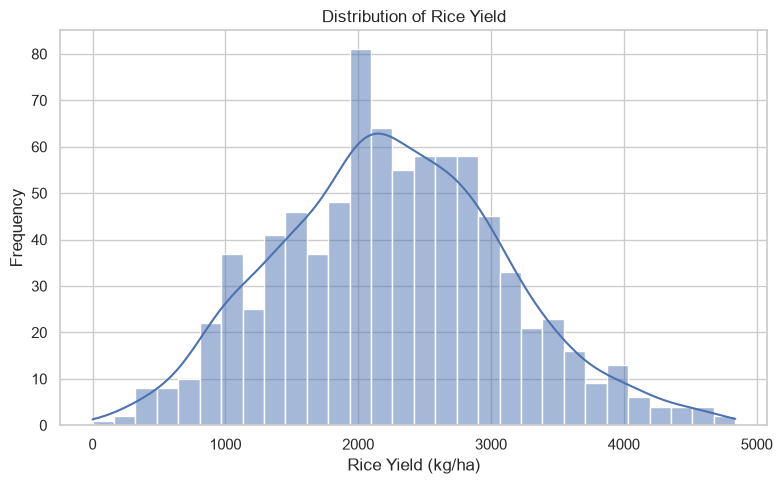

,yield_kg_ha
count,839.000000
mean,2255.246201
std,852.921448
min,0.000000
25%,1662.195220
50%,2234.021070
75%,2825.709914
max,4838.996321


Skewness: 0.176448640148485


In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(df["yield_kg_ha"], bins=30, kde=True, color="C0")
plt.title("Distribution of Rice Yield")
plt.xlabel("Rice Yield (kg/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

display(df["yield_kg_ha"].describe().to_frame("yield_kg_ha"))
print("Skewness:", df["yield_kg_ha"].skew())

## 16.3 Yield outlier analysis

Outliers are identified using the IQR rule. They are **not automatically removed** because unusually high or low agricultural yields may be genuine observations.

In [26]:
q1 = df["yield_kg_ha"].quantile(0.25)
q3 = df["yield_kg_ha"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["yield_kg_ha"] < lower_bound) |
    (df["yield_kg_ha"] > upper_bound)
].copy()

print(f"IQR lower bound: {lower_bound:.2f} kg/ha")
print(f"IQR upper bound: {upper_bound:.2f} kg/ha")
print(f"Number of outlier rows: {len(outliers)}")

IQR lower bound: -83.08 kg/ha
IQR upper bound: 4570.98 kg/ha
Number of outlier rows: 2


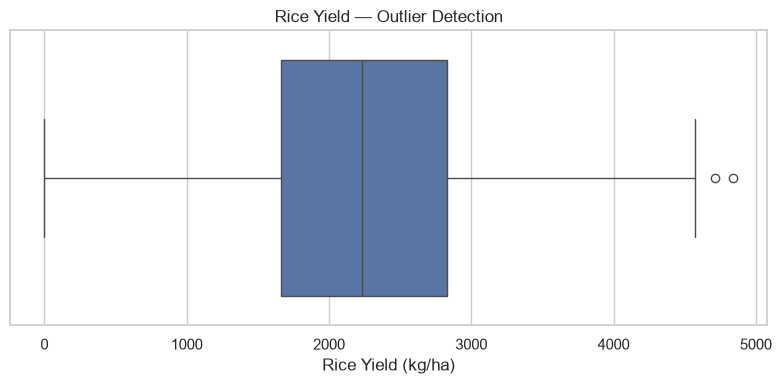

In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["yield_kg_ha"])
plt.title("Rice Yield — Outlier Detection")
plt.xlabel("Rice Yield (kg/ha)")
plt.tight_layout()
plt.show()

In [28]:
if len(outliers) > 0:
    display(
        outliers[["district", "year", "season", "area", "production", "yield_kg_ha"]]
        .sort_values("yield_kg_ha")
    )

,district,year,season,area,production,yield_kg_ha
290,Jharsuguda,2020,Summer,1520.0,7160.0,4710.526316
204,Sambalpur,2021,Summer,10601.0,51298.2,4838.996321


## 16.4 Observations by year

,year,observations
0,2014,79
1,2015,76
2,2016,87
3,2017,86
4,2018,82
5,2019,83
6,2020,86
7,2021,86
8,2022,84
9,2023,30


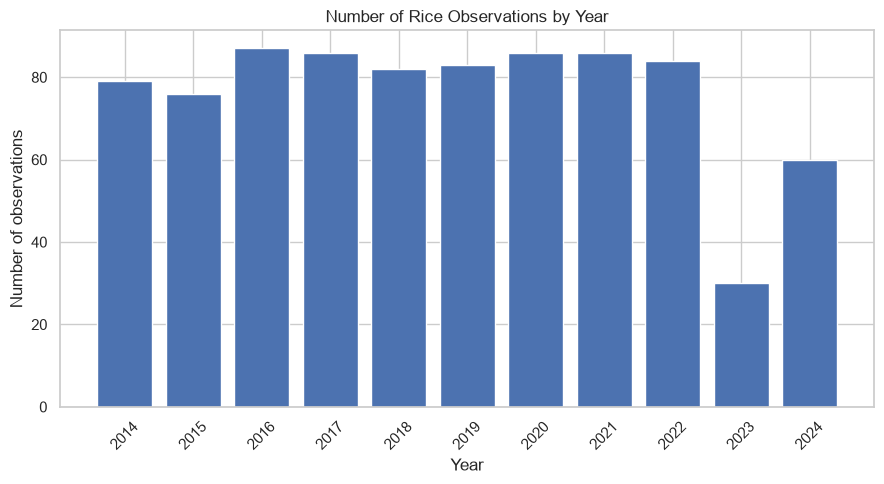

In [29]:
year_counts = df.groupby("year").size().reset_index(name="observations")
display(year_counts)

plt.figure(figsize=(9, 5))
plt.bar(year_counts["year"].astype(str), year_counts["observations"])
plt.title("Number of Rice Observations by Year")
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16.5 Average yield trend over years

,year,count,mean,median,std
0,2014,79,2218.216661,2111.111111,797.855441
1,2015,76,1590.412574,1287.449017,945.621061
2,2016,87,2271.498772,2398.429045,791.611529
3,2017,86,1876.205927,1865.257929,789.581134
4,2018,82,1995.799123,1942.092690,831.462951
5,2019,83,2448.521407,2365.853659,726.722977
6,2020,86,2619.584725,2614.435628,778.571856
7,2021,86,2357.409312,2290.624976,884.037469
8,2022,84,2703.574779,2780.194320,799.558870
9,2023,30,1973.123111,2060.655788,314.580698


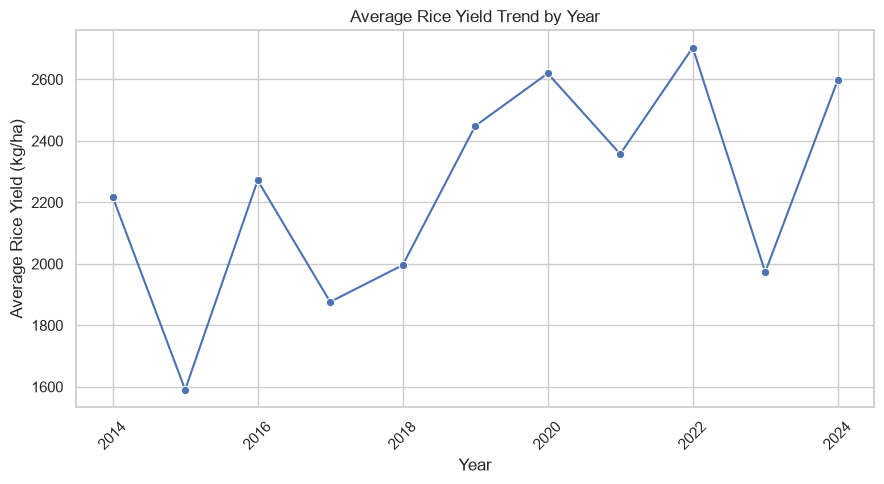

In [30]:
yearly_yield = (
    df.groupby("year")["yield_kg_ha"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(yearly_yield)

plt.figure(figsize=(9, 5))
sns.lineplot(data=yearly_yield, x="year", y="mean", marker="o")
plt.title("Average Rice Yield Trend by Year")
plt.xlabel("Year")
plt.ylabel("Average Rice Yield (kg/ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16.6 Yield by season

In [31]:
season_summary = (
    df.groupby("season")["yield_kg_ha"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(season_summary)

,count,mean,median,std,min,max
season,,,,,,
Summer,282,2831.619962,2796.873646,786.173293,920.000000,4838.996321
Winter,270,2282.483245,2303.861330,694.097307,297.257591,4168.635458
Kharif,60,2168.810538,2158.514098,408.818031,1386.442964,3139.008684
Autumn,227,1529.672356,1509.462860,604.748555,0.000000,3549.413735


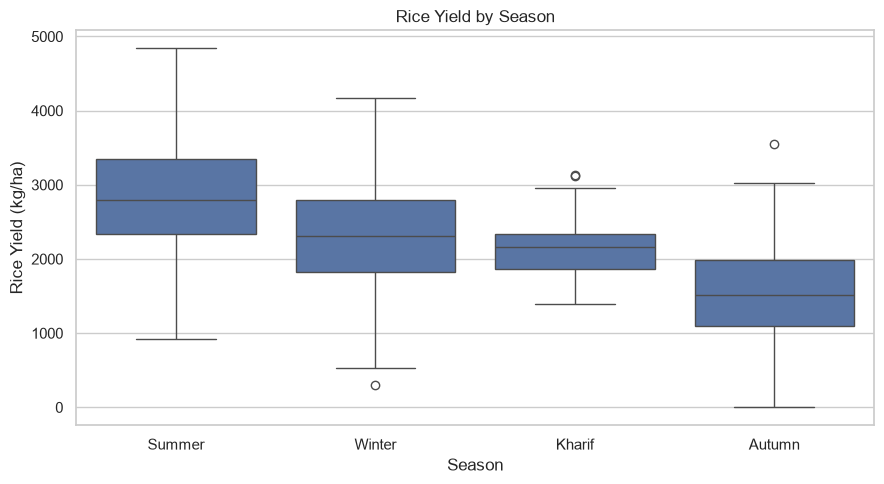

In [32]:
season_order = season_summary.index

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="season", y="yield_kg_ha", order=season_order)
plt.title("Rice Yield by Season")
plt.xlabel("Season")
plt.ylabel("Rice Yield (kg/ha)")
plt.tight_layout()
plt.show()

## 16.7 District-level performance

In [33]:
district_yield = (
    df.groupby("district")["yield_kg_ha"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(district_yield.head(10))
display(district_yield.tail(10).sort_values("mean"))

,count,mean,median,std
district,,,,
Sonepur,30,2976.136103,3219.374578,1049.813809
Balasore,22,2777.666142,3003.484552,770.218316
Cuttack,30,2612.277354,2644.952835,773.558241
Sambalpur,30,2558.689787,2460.153715,1362.063832
Kendujhar,30,2533.739284,2621.179509,766.123303
Boudh,30,2506.111330,2737.766714,771.668952
Puri,23,2498.718492,2544.150425,609.257927
Bargarh,30,2489.364309,2421.909797,1359.120822
Khordha,26,2463.192628,2530.144055,971.577992


,count,mean,median,std
district,,,,
Kandhamal,29,1737.515075,1786.742679,544.348047
Nayagarh,23,1772.005584,2000.000000,769.618532
Sundargarh,30,1790.918007,1801.572741,508.756781
Gajapati,23,1792.453559,1881.355932,549.318715
Jajapur,30,1806.402208,1773.502233,711.241704
Malkangiri,30,1838.903931,1913.009666,561.044641
Deogarh,25,1909.181382,1953.800698,600.815541
Nuapada,30,2073.634139,2205.905894,834.102340
Kendrapara,30,2119.009878,2000.000000,618.480807


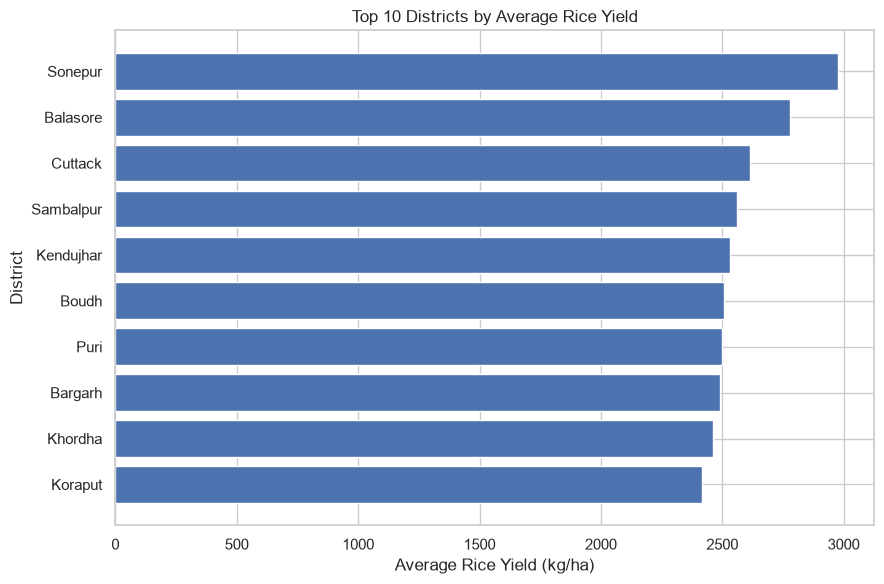

In [34]:
top10 = district_yield.head(10).sort_values("mean")

plt.figure(figsize=(9, 6))
plt.barh(top10.index, top10["mean"])
plt.title("Top 10 Districts by Average Rice Yield")
plt.xlabel("Average Rice Yield (kg/ha)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

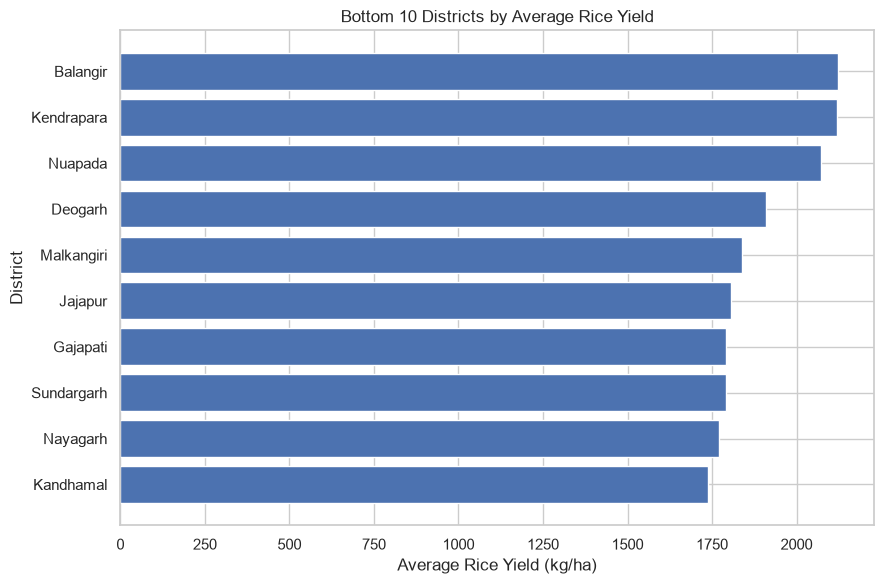

In [35]:
bottom10 = district_yield.tail(10).sort_values("mean", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(bottom10.index, bottom10["mean"])
plt.title("Bottom 10 Districts by Average Rice Yield")
plt.xlabel("Average Rice Yield (kg/ha)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

## 16.8 Seasonal distribution of observations

,observations
season,
Summer,282
Winter,270
Autumn,227
Kharif,60


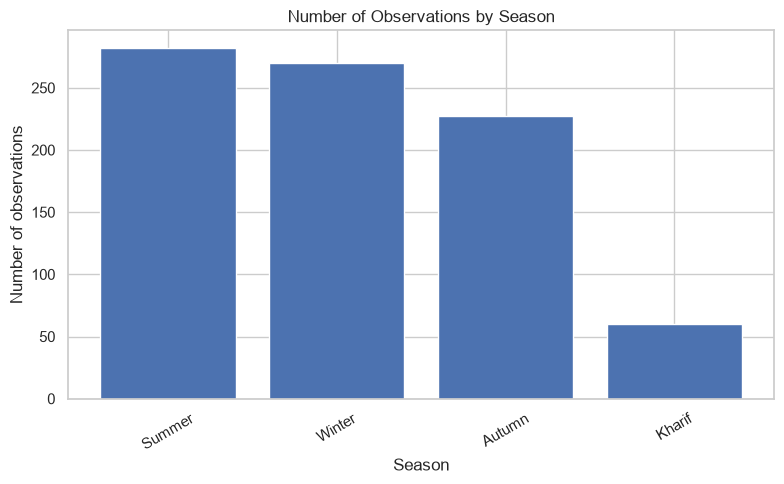

In [36]:
season_counts = df["season"].value_counts().sort_values(ascending=False)
display(season_counts.to_frame("observations"))

plt.figure(figsize=(8, 5))
plt.bar(season_counts.index, season_counts.values)
plt.title("Number of Observations by Season")
plt.xlabel("Season")
plt.ylabel("Number of observations")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 16.9 Climate and soil feature distributions

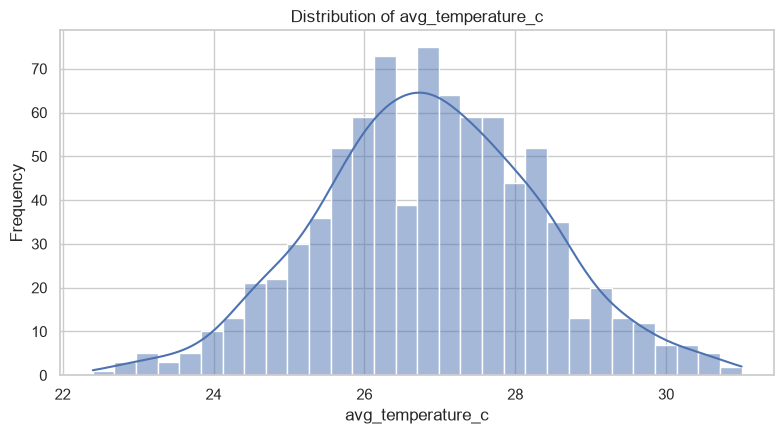

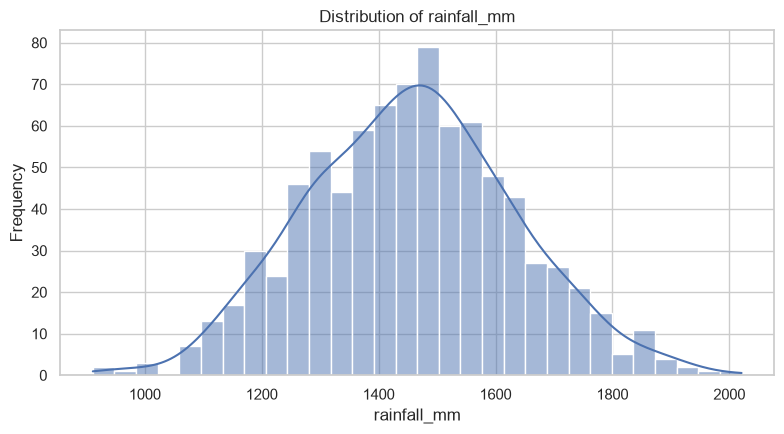

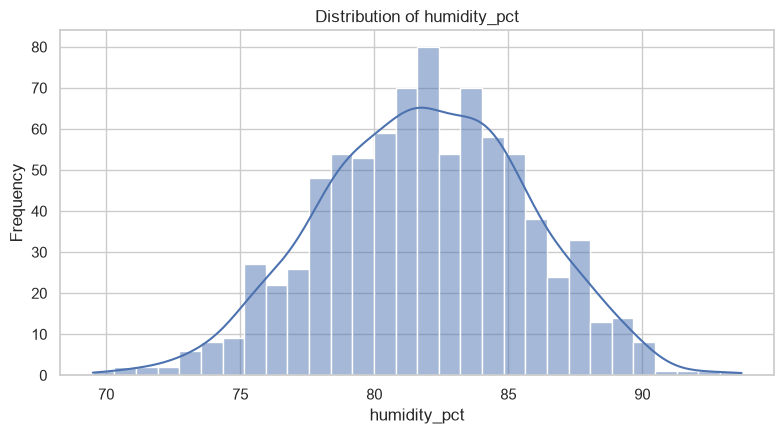

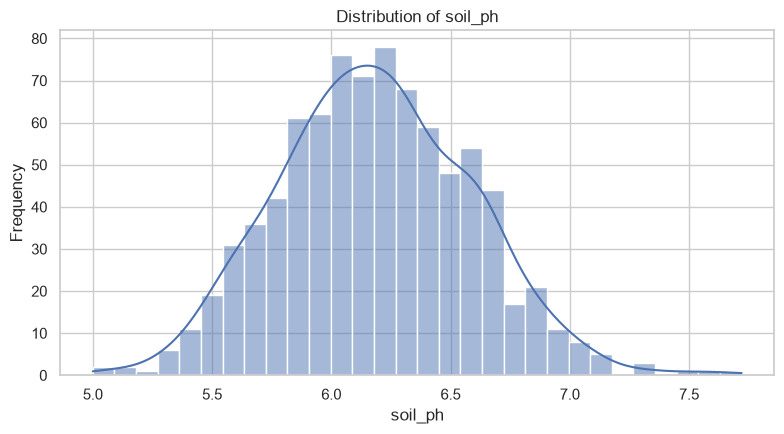

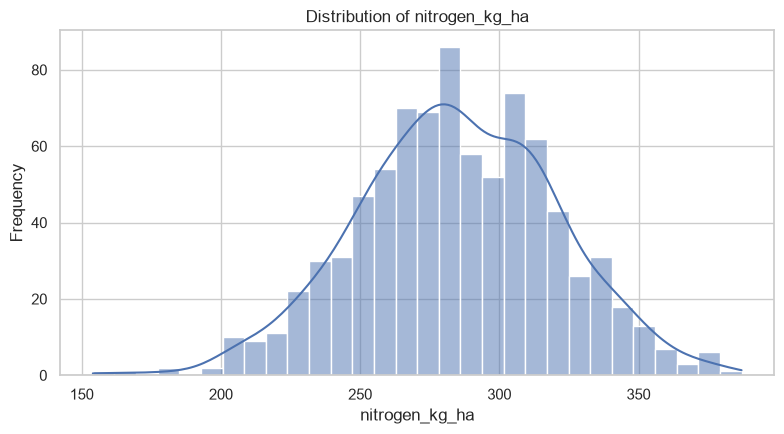

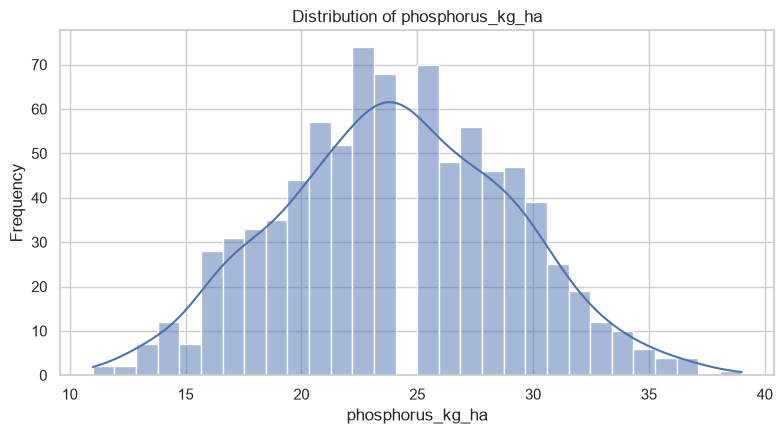

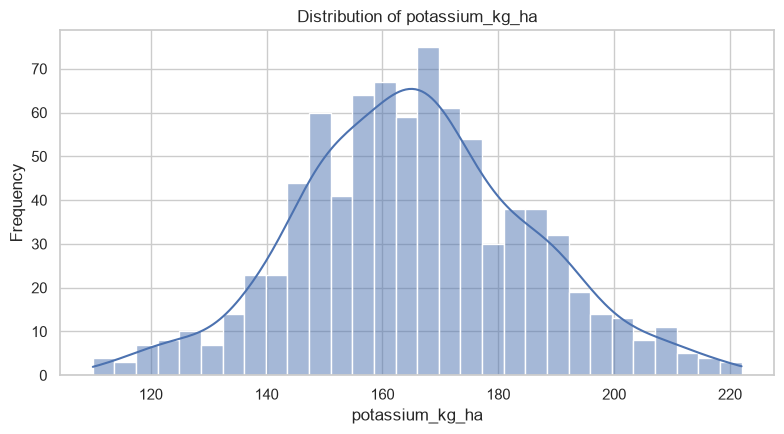

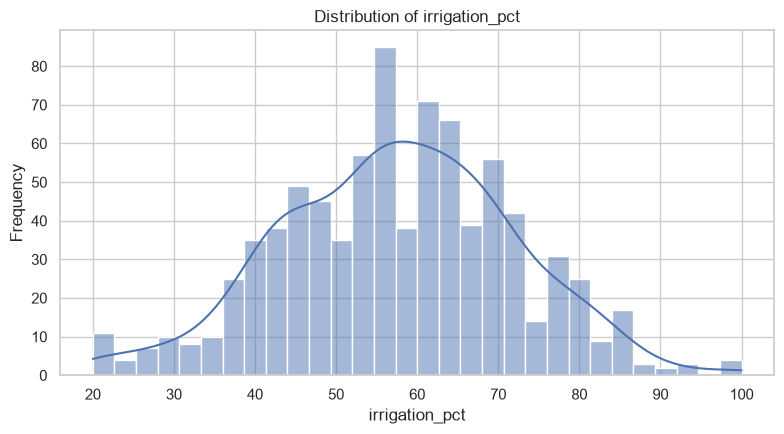

In [37]:
feature_columns = [
    "avg_temperature_c",
    "rainfall_mm",
    "humidity_pct",
    "soil_ph",
    "nitrogen_kg_ha",
    "phosphorus_kg_ha",
    "potassium_kg_ha",
    "irrigation_pct"
]

for col in feature_columns:
    plt.figure(figsize=(8, 4.5))
    sns.histplot(df[col], bins=30, kde=True, color="C0")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 16.10 Feature vs yield relationships

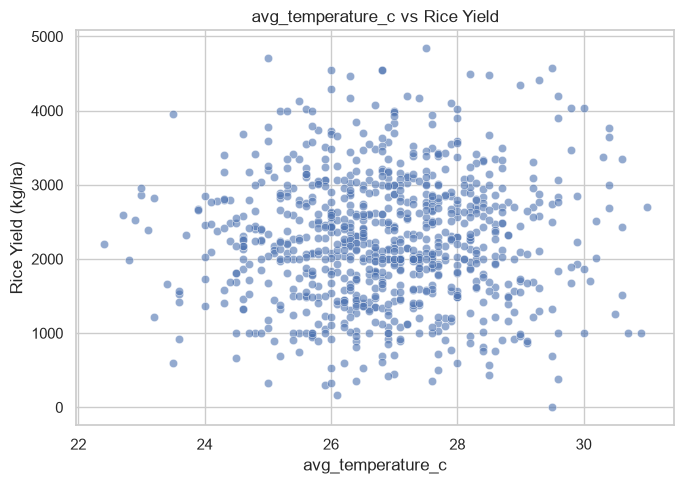

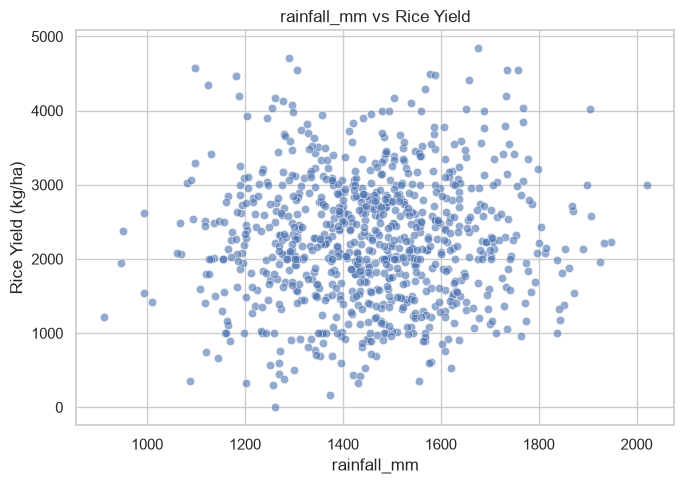

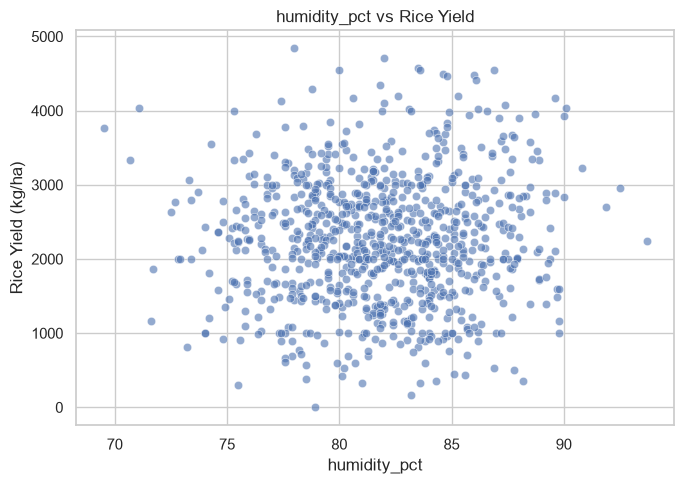

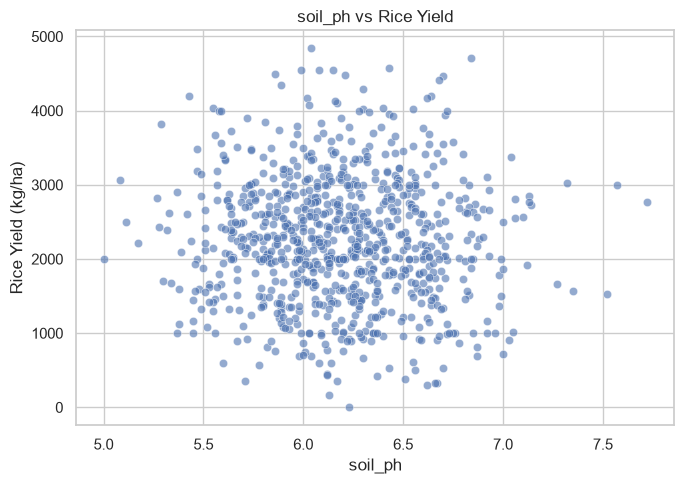

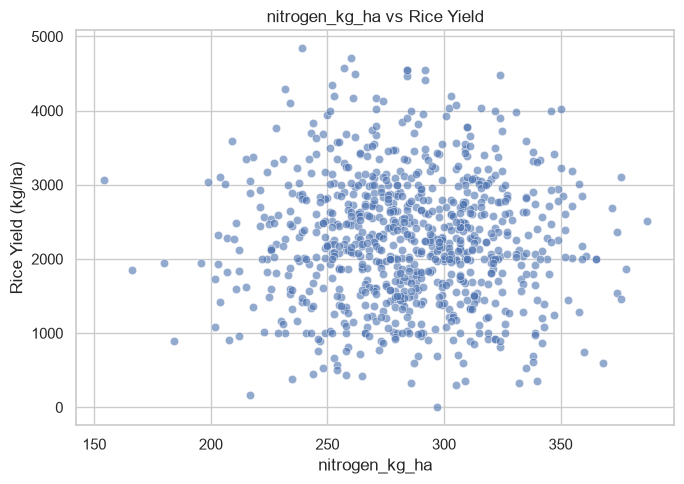

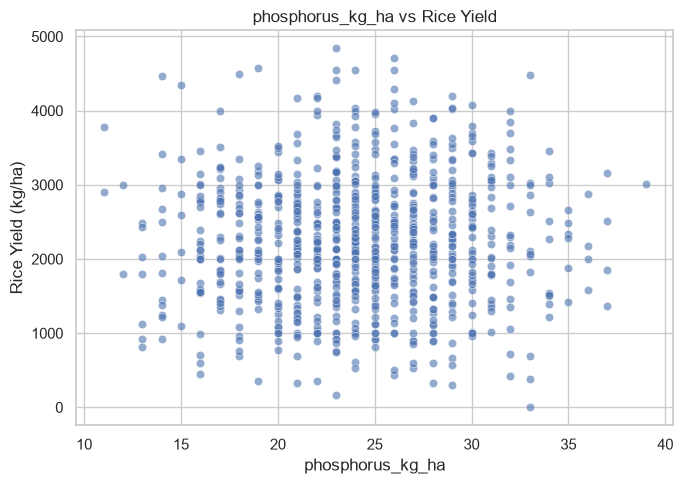

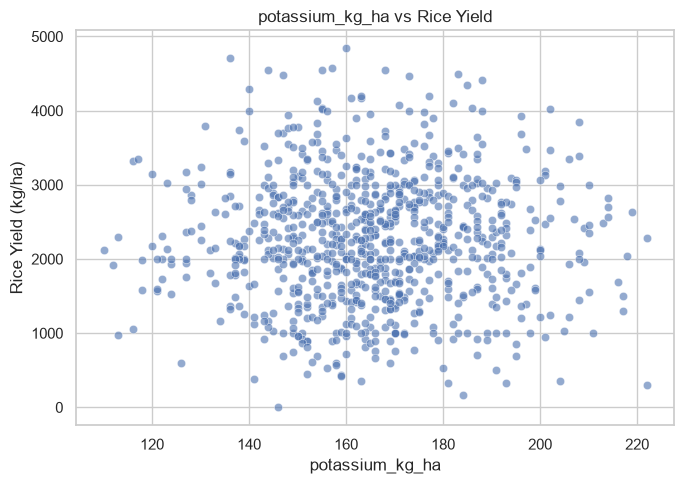

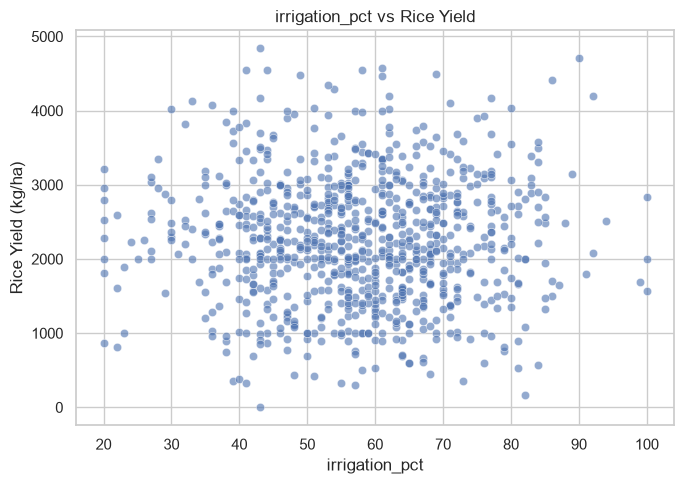

In [38]:
for col in feature_columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=col, y="yield_kg_ha", alpha=0.6)
    plt.title(f"{col} vs Rice Yield")
    plt.xlabel(col)
    plt.ylabel("Rice Yield (kg/ha)")
    plt.tight_layout()
    plt.show()

## 16.11 Area vs yield

Area is retained as a potential ML feature. Production is **not** used as an ML feature because yield is directly derived from production and area.

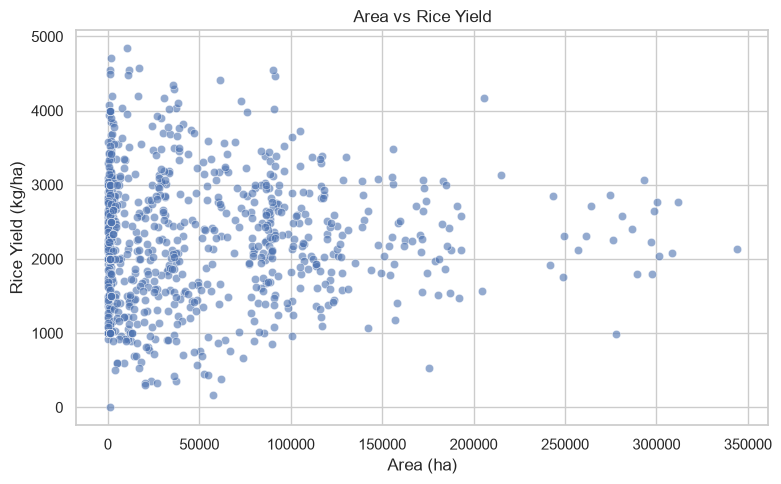

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="area", y="yield_kg_ha", alpha=0.6)
plt.title("Area vs Rice Yield")
plt.xlabel("Area (ha)")
plt.ylabel("Rice Yield (kg/ha)")
plt.tight_layout()
plt.show()

## 16.12 Rainfall and temperature trends

In [40]:
climate_by_year = (
    df.groupby("year")[["rainfall_mm", "avg_temperature_c", "humidity_pct"]]
    .mean()
    .reset_index()
)

display(climate_by_year)

,year,rainfall_mm,avg_temperature_c,humidity_pct
0,2014,1442.316456,26.855696,82.158228
1,2015,1449.894737,26.935526,81.690789
2,2016,1459.632184,26.773563,81.709195
3,2017,1449.313953,26.741860,81.861628
4,2018,1435.073171,26.871951,82.051220
5,2019,1444.421687,26.931325,81.771084
6,2020,1447.627907,26.660465,81.145349
7,2021,1487.825581,26.850000,82.588372
8,2022,1450.119048,26.928571,82.142857
9,2023,1497.300000,26.893333,81.740000


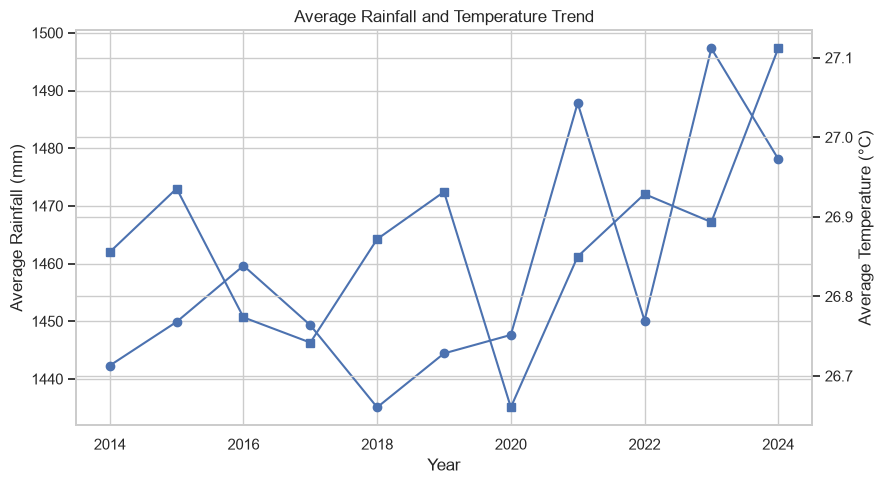

In [41]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    climate_by_year["year"],
    climate_by_year["rainfall_mm"],
    marker="o",
    label="Rainfall (mm)"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Rainfall (mm)")

ax2 = ax1.twinx()
ax2.plot(
    climate_by_year["year"],
    climate_by_year["avg_temperature_c"],
    marker="s",
    label="Temperature (°C)"
)
ax2.set_ylabel("Average Temperature (°C)")

ax1.set_title("Average Rainfall and Temperature Trend")
fig.tight_layout()
plt.show()

## 16.13 Soil pH, nutrients and irrigation vs yield

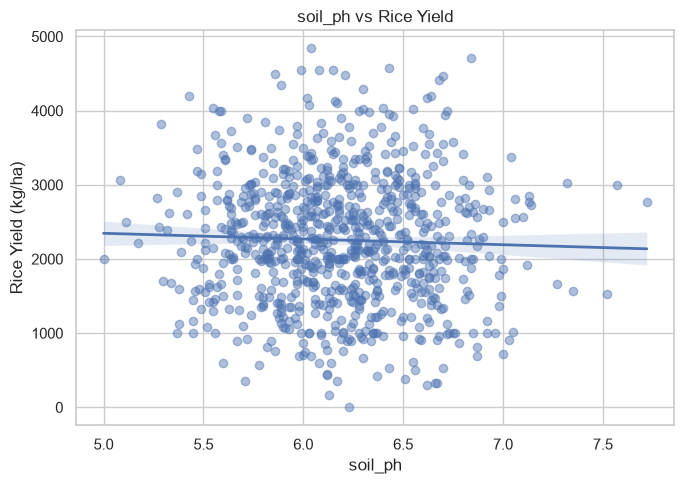

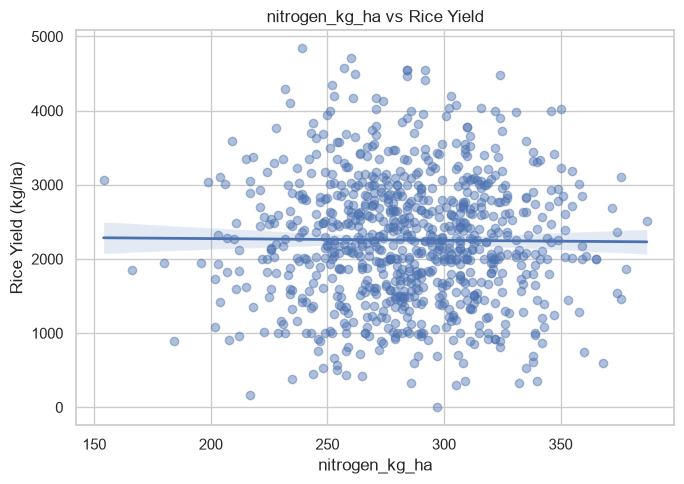

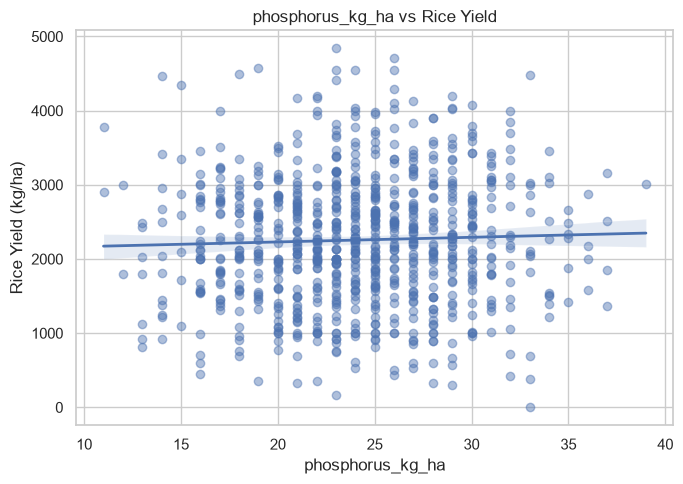

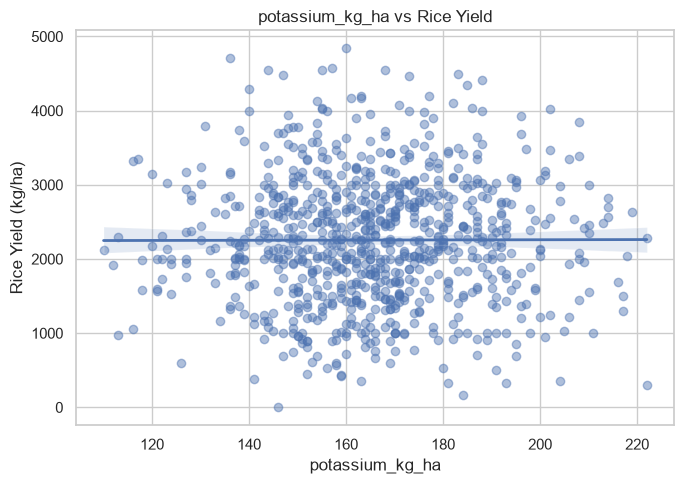

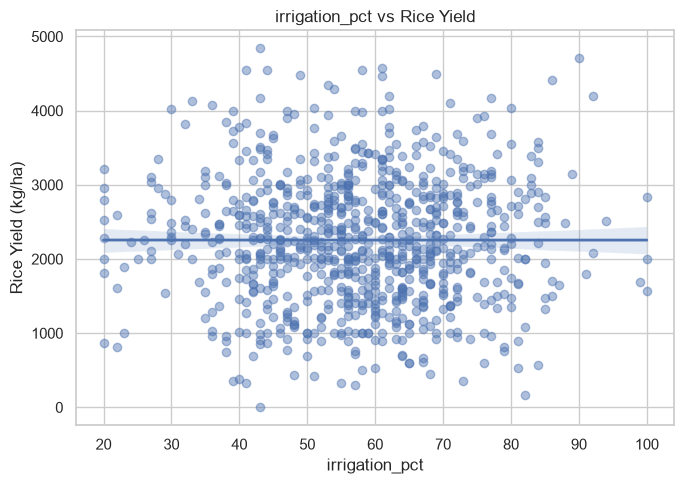

In [42]:
soil_nutrient_features = [
    "soil_ph",
    "nitrogen_kg_ha",
    "phosphorus_kg_ha",
    "potassium_kg_ha",
    "irrigation_pct"
]

for col in soil_nutrient_features:
    plt.figure(figsize=(7, 5))
    sns.regplot(
        data=df,
        color="C0",
        x=col,
        y="yield_kg_ha",
        scatter_kws={"alpha": 0.45},
        line_kws={"linewidth": 2}
    )
    plt.title(f"{col} vs Rice Yield")
    plt.xlabel(col)
    plt.ylabel("Rice Yield (kg/ha)")
    plt.tight_layout()
    plt.show()

## 16.14 Correlation analysis

In [43]:
numerical = df.select_dtypes(include=np.number)
corr = numerical.corr()

display(
    corr["yield_kg_ha"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_yield")
)

,correlation_with_yield
yield_kg_ha,1.000000
year,0.248253
production,0.241039
reported_crop_yield,0.109300
rainfall_mm,0.051854
humidity_pct,0.045405
phosphorus_kg_ha,0.036708
avg_temperature_c,0.029371
area,0.024966
potassium_kg_ha,0.002731


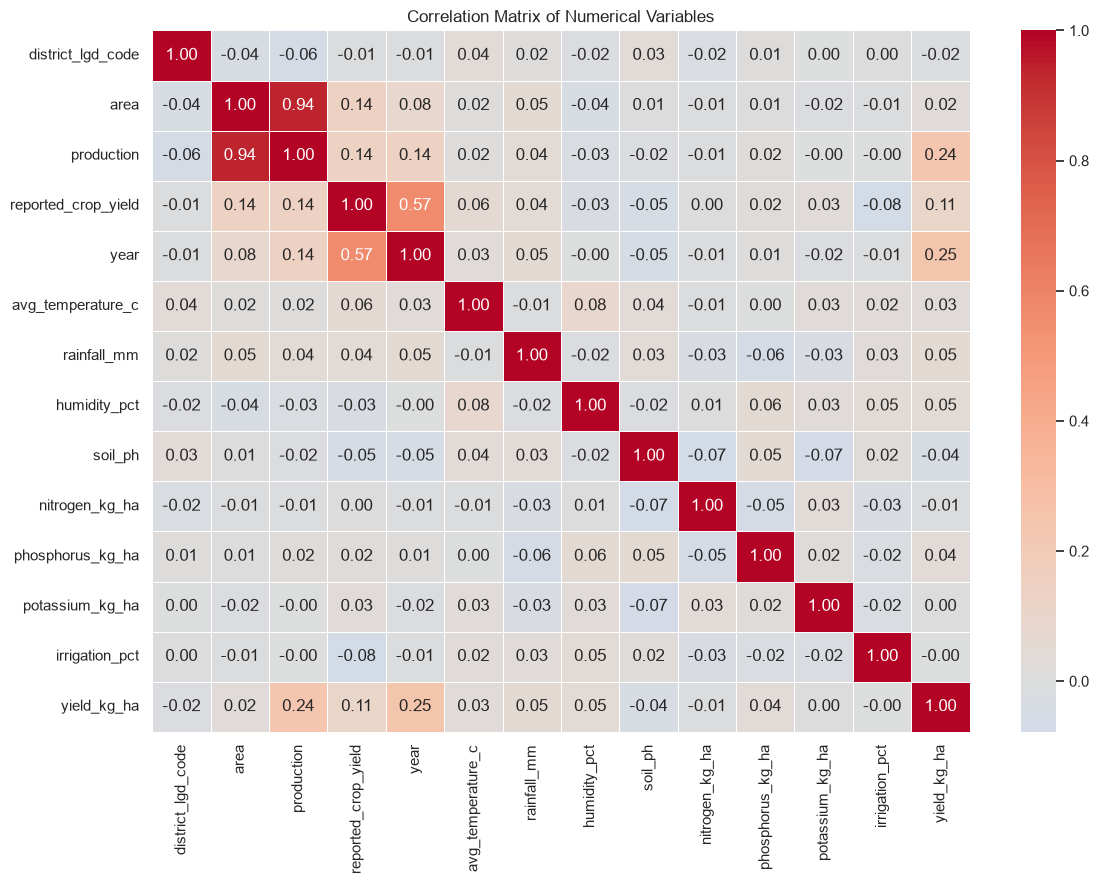

In [44]:
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 16.15 Area vs production — data validation view

This relationship is expected because production and yield are mathematically related to area. It is useful for understanding the agricultural data, but **production will not be supplied to the ML model**.

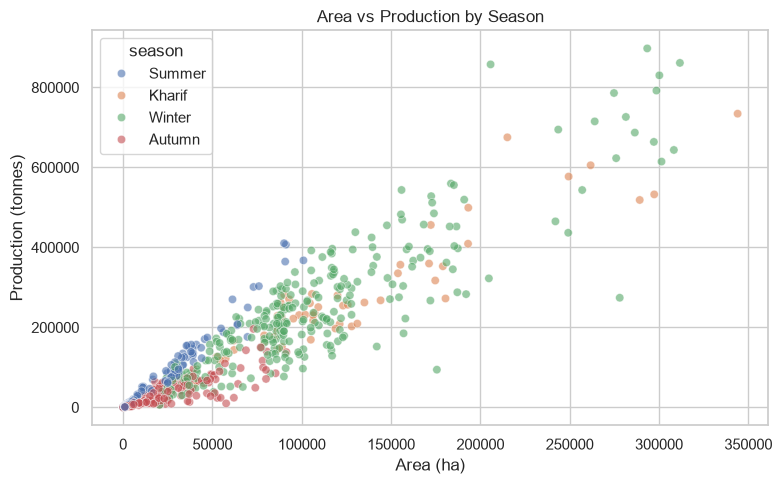

In [45]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="area", y="production", hue="season", alpha=0.6)
plt.title("Area vs Production by Season")
plt.xlabel("Area (ha)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

# 17. EDA findings summary

In [46]:
# Automatically generate a few key summary values for the report.
best_season = season_summary["mean"].idxmax()
worst_season = season_summary["mean"].idxmin()
best_district = district_yield["mean"].idxmax()
worst_district = district_yield["mean"].idxmin()

print(f"Final district-level observations used for EDA: {len(df)}")
print(f"Number of districts: {df['district'].nunique()}")
print(f"Year range: {df['year'].min()}–{df['year'].max()}")
print(f"Average yield: {df['yield_kg_ha'].mean():.2f} kg/ha")
print(f"Median yield: {df['yield_kg_ha'].median():.2f} kg/ha")
print(f"Yield skewness: {df['yield_kg_ha'].skew():.3f}")
print(f"Highest-average-yield season: {best_season} ({season_summary.loc[best_season, 'mean']:.2f} kg/ha)")
print(f"Lowest-average-yield season: {worst_season} ({season_summary.loc[worst_season, 'mean']:.2f} kg/ha)")
print(f"Highest-average-yield district: {best_district} ({district_yield.loc[best_district, 'mean']:.2f} kg/ha)")
print(f"Lowest-average-yield district: {worst_district} ({district_yield.loc[worst_district, 'mean']:.2f} kg/ha)")

Final district-level observations used for EDA: 839
Number of districts: 30
Year range: 2014–2024
Average yield: 2255.25 kg/ha
Median yield: 2234.02 kg/ha
Yield skewness: 0.176
Highest-average-yield season: Summer (2831.62 kg/ha)
Lowest-average-yield season: Autumn (1529.67 kg/ha)
Highest-average-yield district: Sonepur (2976.14 kg/ha)
Lowest-average-yield district: Kandhamal (1737.52 kg/ha)


### Main EDA conclusions

- The two datasets can be integrated using `fiscal_year`, `district_lgd_code`, `crop` and `season`.
- State-total records are excluded before merging so that the analysis remains district-level.
- The final integrated district-level dataset contains **869 matched observations** before removing missing-target rows.
- **30 observations** have missing production/yield, all associated with **2023 Summer**, leaving **839 complete observations** for supervised ML.
- Yield is represented consistently as **kg/ha** using `production × 1000 / area`.
- District and season provide important categorical context and should be retained for ML rather than treated as numeric measurements.
- Production is useful for EDA and validation, but it should be excluded from ML predictors because it is mathematically linked to yield.
- The weak/strong relationships observed in the correlation analysis should not be interpreted as proof of causality; nonlinear models can capture relationships that simple Pearson correlation does not.

# 18. ML-ready feature definition

The next notebook stage can use:

### Target
`yield_kg_ha`

### Numerical features
- `area`
- `year`
- `avg_temperature_c`
- `rainfall_mm`
- `humidity_pct`
- `soil_ph`
- `nitrogen_kg_ha`
- `phosphorus_kg_ha`
- `potassium_kg_ha`
- `irrigation_pct`

### Categorical features
- `district`
- `season`

### Excluded from ML predictors
- `production` — data leakage because yield is derived from production and area.
- `district_lgd_code` — identifier, not a continuous measurement.
- `district_source` — raw naming variant retained only for traceability.
- `reported_crop_yield` — redundant/affected by unit representation; use the consistent `yield_kg_ha` target instead.
- `fiscal_year` — redundant with `year` for the current modeling setup.

## 19. Save the final cleaned dataset

This CSV is the direct hand-off from EDA to the ML notebook.

In [47]:
OUTPUT_PATH = "odisha_rice_integrated_eda_clean.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")

Saved: odisha_rice_integrated_eda_clean.csv
